In [29]:
import numpy as np
import pandas as pd

In [30]:
data = pd.read_csv("../data/BTC_ETH.csv")

In [31]:
data

,Timestamp,BTC,ETH
0,2017-04-02,1099.169125,48.55
1,2017-04-03,1141.813000,44.13
2,2017-04-04,1141.600363,44.43
3,2017-04-05,1133.079314,44.90
4,2017-04-06,1196.307937,43.23
...,...,...,...
360,2018-03-28,7960.380000,445.93
361,2018-03-29,7172.280000,383.90
362,2018-03-30,6882.531667,393.82
363,2018-03-31,6935.480000,394.07


<Axes: >

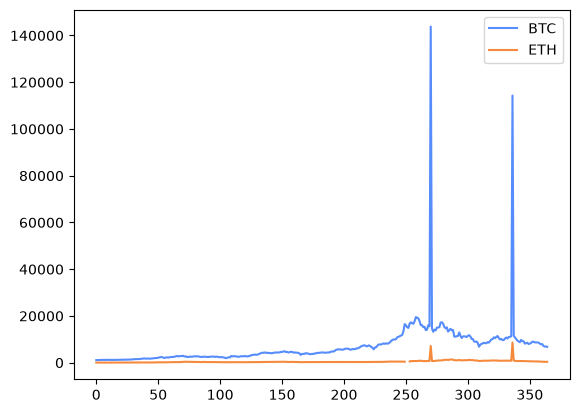

In [32]:
data.plot()

In [33]:
for row in range(len(data)):
    current = data["BTC"][row]
    if row != 0:
        previous = data["BTC"][row-1]
        if abs(current - previous) > previous: # Wenn das jetztige Element doppelt so groß ist, wie das vorherige Element
            print(current)
            print(row)

143805.81666666668
270
114301.81666666664
336


In [34]:
data["BTC"] [270]

np.float64(143805.81666666668)

In [35]:
left = data['BTC'][269]
right = data["BTC"][271]
avg = (left+right)/2
avg

np.float64(15114.730833333331)

In [36]:
data.loc[270, "BTC"] = avg

<Axes: >

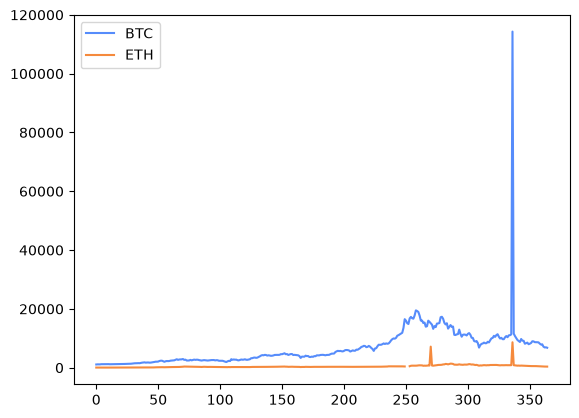

In [37]:
data.plot()

In [38]:
def findOutlier(columnName):
    for row in range(len(data)):
        if row == 0:
            continue

        current = data[columnName][row]
        previous = data[columnName][row-1]

        if abs(current - previous) > previous: # Wenn das jetztige Element doppelt so groß ist, wie das vorherige Element
            print(current)
            print(row)

In [39]:
findOutlier("BTC")

114301.81666666664
336


In [40]:
findOutlier("ETH")

7166.9
270
8648.3
336


In [41]:
def fixOutlier(columnName, index):
    left = data[columnName][index-1]
    right = data[columnName][index+1]
    avg = (left+right)/2
    data.loc[index, columnName] = avg

In [42]:
fixOutlier("BTC", 336)
fixOutlier("ETH", 336)
fixOutlier("ETH", 270)

<Axes: >

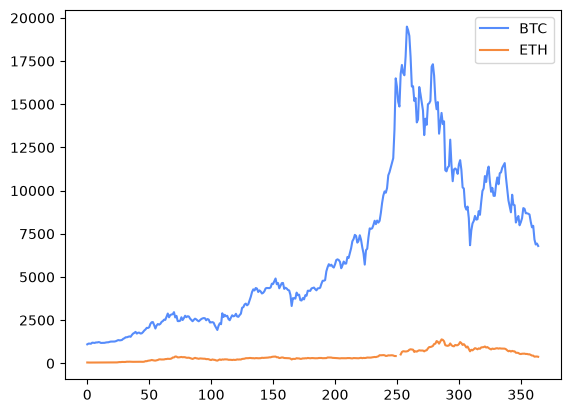

In [43]:
data.plot()

In [44]:
data[data["ETH"].isnull()]

,Timestamp,BTC,ETH
250,2017-12-08,16007.436667,NaN
251,2017-12-09,15142.834152,NaN
252,2017-12-10,14869.805000,NaN


<Axes: >

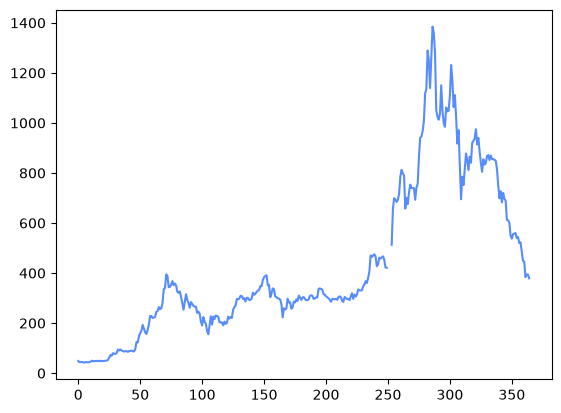

In [45]:
data["ETH"].plot()

<Axes: >

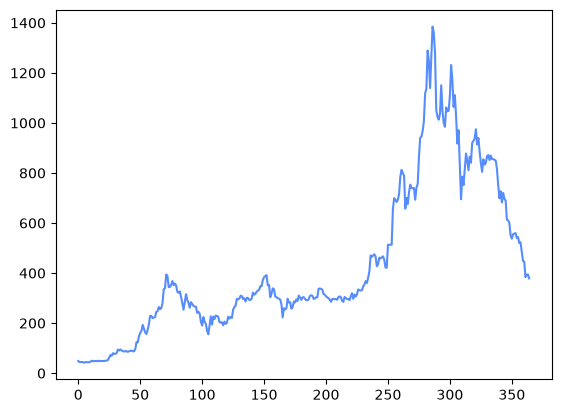

In [46]:
data.bfill()["ETH"].plot()

In [47]:
data.loc[250, "ETH"] = data["ETH"][249]

In [48]:
data.loc[252, "ETH"] = data["ETH"][253]

In [49]:
fixOutlier("ETH", 251)

<Axes: >

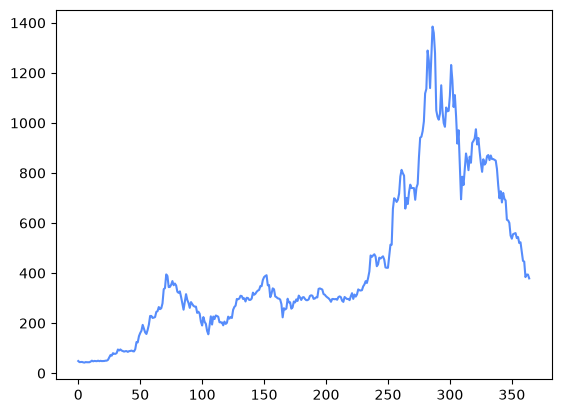

In [50]:
data.bfill()["ETH"].plot()

<Axes: >

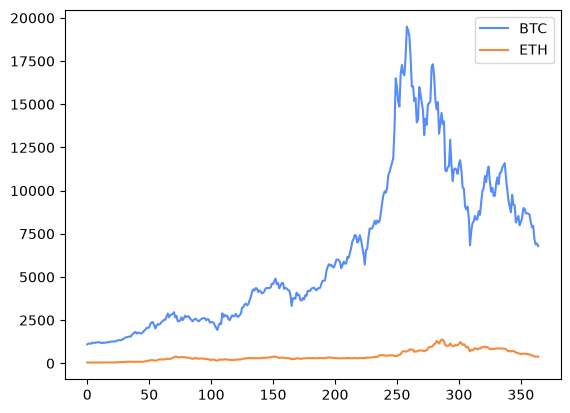

In [51]:
data.plot()